# **CNN** vs **SVM** model

#**Step 1:**
##**1. Core Objectives**

####**- Standardization:**

 To transform raw, inconsistently sized images into a uniform mathematical format (tensors/arrays) that both SVM and CNN models can process.
####**- Dimensionality Management:**
 Resizing images to $64 \times 64$ to balance the detail needed for the CNN with the computational limits of the SVM.
####**- Resource Setup:**
Initializing the local directory structure within the Google Colab environment to hold the dataset.

#**2. Step-by-Step Breakdown**
###**A. Environment & Directory Setup**
```!mkdir -p dataset/Cat dataset/Dog```

Action: This shell command creates the folder hierarchy required for the load_data function to scan.

Purpose: It ensures the code doesn't crash due to "Folder Not Found" errors.

###**B. The ```load_data``` Function (The Preprocessing Engine)**
This is where the raw data is converted into a format the computer understands:

####**1. Iterative Scanning:**
It loops through the ```cat``` and ```Dog``` folders, assigning Label 0 to cats and Label 1 to dogs.

####**2. Color Correction (```cv2.cvtColor```):**
 OpenCV reads images in BGR (Blue-Green-Red). Since most models and human vision expect RGB, this step is crucial for maintaining the integrity of the features.

####**3. Dimensionality Resizing (```cv2.resize```):**
 All images must have the same "shape" (width/height) before being converted into a NumPy array.

####**4. Error Handling (```try-except```):**
 It skips corrupted images or non-image files, ensuring the training process isn't interrupted by a single "bad" file.

###**C. Data Packaging**
```return np.array(images), np.array(labels)```

Action: Converts the list of processed images into a high-performance NumPy Array.

Purpose: Machine learning libraries (Scikit-Learn and TensorFlow) require data in array format to perform matrix multiplications during the "learning" phase.

In [20]:
# --- 1: SETUP & DATA LOADING ---
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models

# Create folders in Colab
!mkdir -p dataset/Cat dataset/Dog

# ---- Data loading function ----
def load_data(base_path, img_size=64):
    images, labels = [], []
    for label, category in enumerate(['Cat', 'Dog']):
        folder = os.path.join(base_path, category)
        if not os.path.exists(folder): continue
        for fname in os.listdir(folder)[:500]:
            try:
                img = cv2.imread(os.path.join(folder, fname))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (img_size, img_size))
                images.append(img)
                labels.append(label)
            except: continue
    return np.array(images), np.array(labels)

print("Setup complete.")

Setup complete.


##**Step 2**
##**1. Core Objectives**
###**Numerical Stability:**
 To scale pixel values into a range that prevents mathematical "overflow" or vanishing gradients during neural network training.

###**Generalization Testing:**
 To separate the data so the model can be tested on images it has never seen before, proving it has "learned" rather than just "memorized."

###**Class Balance:**
 To ensure both the training and testing sets have an equal proportion of cats and dogs.


In [21]:
# ---- 2: PREPROCESSING ----
X, y = load_data('dataset')

if len(X) > 0:
    # Optimization: Scaling pixels to [0,1]
    X = X.astype('float32') / 255.0
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    print(f"Data ready: {len(X_train)} training images, {len(X_test)} testing images.")
else:
    print("No images found. Please upload images to the dataset folders.")

Data ready: 800 training images, 200 testing images.


##**Step 3**
###**1. Core Objectives**
####**Vectorization:**
 Converting spatial 2D image grids into 1D numerical vectors so the SVM can plot them in a high-dimensional space.

####**Feature Standardization:**
 Ensuring all features (pixels) have a mean of 0 and a variance of 1, which is a requirement for the SVM algorithm to function correctly.

####**Decision Boundary Optimization:**
 Finding the "Optimal Hyperplane" that maximizes the margin between the Cat and Dog classes.

In [22]:
# --- 3: SVM TRAINING ---
print("Training SVM...")
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

# Optimization: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

svm_model = SVC(kernel='rbf', C=1.0)
svm_model.fit(X_train_scaled, y_train)
svm_preds = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_preds)
print(f"SVM Accuracy: {svm_acc * 100:.2f}%")

Training SVM...
SVM Accuracy: 61.00%


##**Step 4**
###**1. Core Objectives**
####**Automatic Feature Engineering:**
 To move away from "hand-crafted" features (flattening) and allow the model to learn its own visual filters (like edges, fur, or ears).

####**Dimensionality Reduction:**
 To compress large image data into meaningful patterns using pooling layers.

####**Generalization through Regularization:**
 To prevent the model from over-fitting (memorizing) the training data so it performs well on new images.

In [23]:
# ---  4: CNN TRAINING ---
print("Training CNN...")
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = cnn_model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test), verbose=1)
cnn_acc = history.history['val_accuracy'][-1]

Training CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - accuracy: 0.4881 - loss: 0.6955 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - accuracy: 0.4798 - loss: 0.6963 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.5441 - loss: 0.6859 - val_accuracy: 0.5100 - val_loss: 0.6920
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.5085 - loss: 0.6906 - val_accuracy: 0.4950 - val_loss: 0.6913
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - accuracy: 0.5382 - loss: 0.6843 - val_accuracy: 0.5350 - val_loss: 0.6886
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - accuracy: 0.5651 - loss: 0.6783 - val_accuracy: 0.5600 - val_loss: 0.6883
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.5630 - loss: 0.6794 - val_accuracy: 0.5400 - val_loss: 0.6875
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 192ms/step - accuracy: 0.6063 - loss: 0.6667 - val_accuracy: 0.

##**Step 5**
###**1. Core Objectives**
Benchmarking: To provide a direct "head-to-head" comparison between the Classical and Deep Learning approaches.

####**Training Diagnostics:**
 To detect issues like Overfitting (memorization) or Underfitting by analyzing the learning curves.

####**Error Analysis:**
 To pinpoint exactly where the models fail (e.g., does the model confuse a specific breed of dog for a cat?).

####**Statistical Validation:**
 To move beyond simple accuracy and provide detailed metrics like Precision, Recall, and F1-Score.

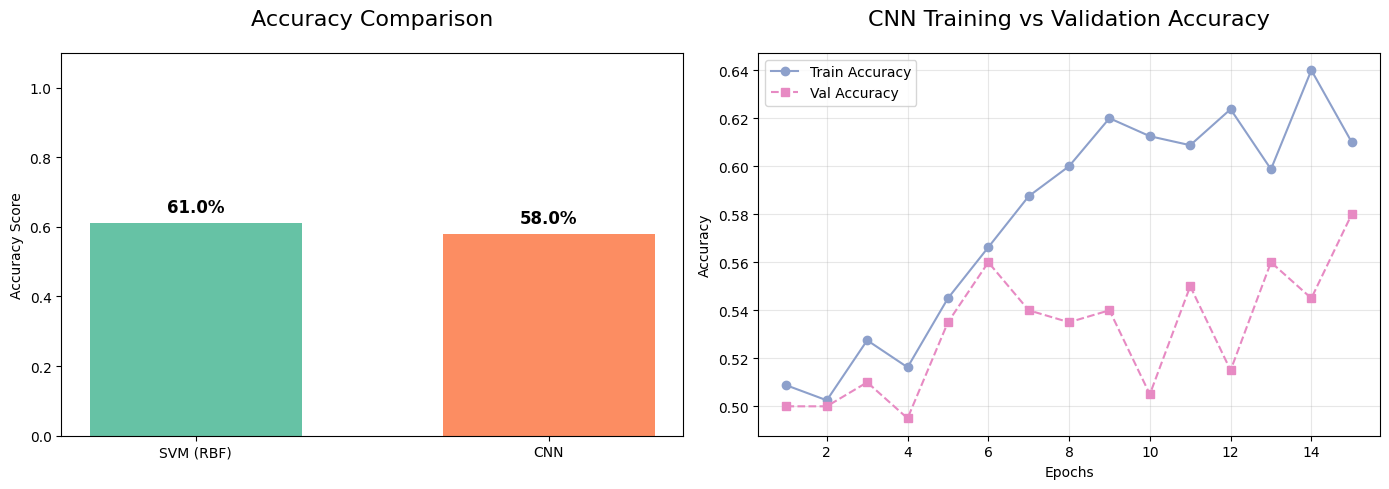

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


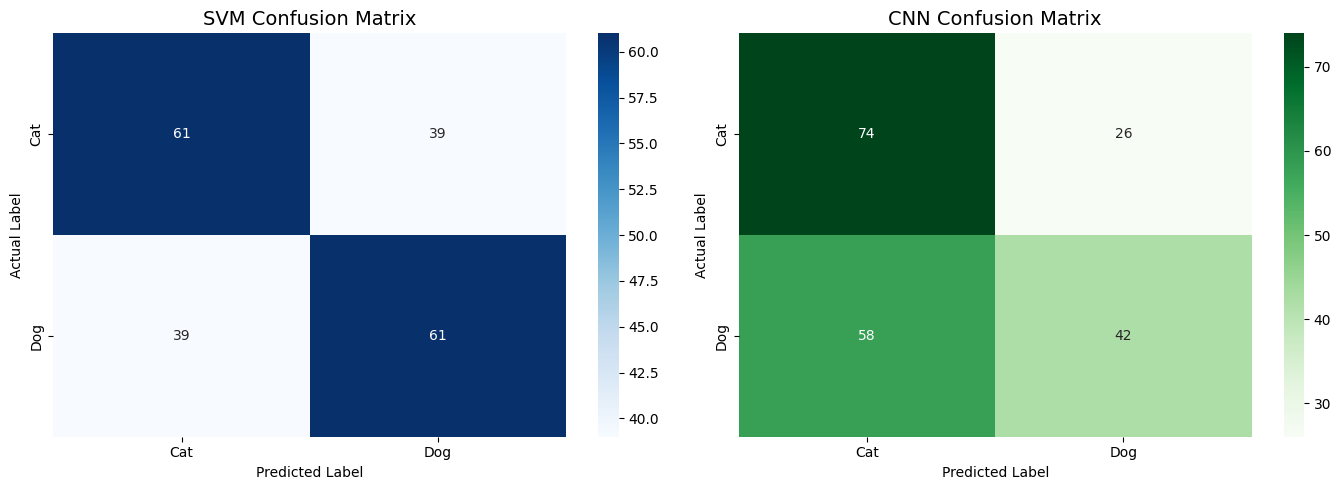


             DETAILED CLASSIFICATION REPORTS

 SVM (Classical ML) Performance:
              precision    recall  f1-score   support

         Cat       0.61      0.61      0.61       100
         Dog       0.61      0.61      0.61       100

    accuracy                           0.61       200
   macro avg       0.61      0.61      0.61       200
weighted avg       0.61      0.61      0.61       200


 CNN (Deep Learning) Performance:
              precision    recall  f1-score   support

         Cat       0.56      0.74      0.64       100
         Dog       0.62      0.42      0.50       100

    accuracy                           0.58       200
   macro avg       0.59      0.58      0.57       200
weighted avg       0.59      0.58      0.57       200



In [24]:
# ---  5: VISUALIZATION ---
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# --- 1. Accuracy Comparison Bar Plot ----
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
models_list = ['SVM (RBF)', 'CNN']
# Ensure these variables were defined in previous cells
accuracies = [svm_acc, cnn_acc]

bars = plt.bar(models_list, accuracies, color=['#66c2a5', '#fc8d62'], width=0.6)
plt.title('Accuracy Comparison', fontsize=16, pad=20)
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.1) # Set slightly higher than 1.0 to fit labels

# Annotate values on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# ---- 2. CNN Learning Curve ----
plt.subplot(1, 2, 2)
# Using 'history' variable from the cnn_model.fit() output
epochs_range = range(1, len(history.history['accuracy']) + 1)
plt.plot(epochs_range, history.history['accuracy'], 'o-', label='Train Accuracy', color='#8da0cb')
plt.plot(epochs_range, history.history['val_accuracy'], 's--', label='Val Accuracy', color='#e78ac3')
plt.title('CNN Training vs Validation Accuracy', fontsize=16, pad=20)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- 3. Confusion Matrices ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SVM Confusion Matrix
svm_cm = confusion_matrix(y_test, svm_preds)
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'],
            ax=axes[0])
axes[0].set_title('SVM Confusion Matrix', fontsize=14)
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# CNN Confusion Matrix
# We calculate cnn_preds here using the cnn_model variable
cnn_preds = (cnn_model.predict(X_test) > 0.5).astype(int).flatten()
cnn_cm = confusion_matrix(y_test, cnn_preds)
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'],
            ax=axes[1])
axes[1].set_title('CNN Confusion Matrix', fontsize=14)
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# ---- 4. Final Classification Reports ----
print("\n" + "="*60)
print("             DETAILED CLASSIFICATION REPORTS")
print("="*60)

print("\n SVM (Classical ML) Performance:")
print(classification_report(y_test, svm_preds, target_names=['Cat', 'Dog']))

print("\n CNN (Deep Learning) Performance:")
print(classification_report(y_test, cnn_preds, target_names=['Cat', 'Dog']))